In [3]:
import pickle
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
from loguru import logger
import matplotlib.pyplot as plt

from behave_analysis.process.session import get_experiment
from behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.helper.model import compute_accuracy_data, plot_accuracy_across_sessions
from behave_analysis.analyze.overview.homing_analysis.decoding_spatial_eff.helper.data_gen import produce_data, create_the_past_design_matrix

# Importing the mice sessions to use

In [4]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may, JAL8_flip3_7may

# Defined session names, experiments and hash mice to sessions

In [5]:
# The values must be in order of data for the code to work
mice_groups = {
    "JAL6": ['JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_flip2_12mar', 'JAL7_flip5_22mar', 'JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', "JAL8_flip3_7may", 'JAL8_14may'],
    "JAL4": ['JAL4_28aug', 'JAL4_3rdSept', 'JAL4_11thSept', 'JAL4_19thSept'],
    "JAL5": ['JAL5_8thSept', 'JAL5_21stSept']}

# The experiment objects index must match the session name index for the code to work
experiments_objects = [JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may, JAL8_flip3_7may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

# The session name indexes must match the experiment object indexes
session_names = ["JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept",
                 "JAL5_8thSept", "JAL5_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may", "JAL8_flip3_7may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

If you haven't created the data already, the produce data function will create the relevant design matrices and classes for logistic regression to run. The last arugmnet, which is a function specific to how the design matrix is created, determines whether we look in the past before the mouse has done the homings, or whether we want to run the decoding during the homing. Only the option looking before the homing has started is included, as this minimises spurious correlations with behaviour. 

In [ ]:
#produce_data(experiments_objects, session_names, "compute_the_first_20_frames_before_homing", create_the_past_design_matrix)
test
#produce_data(experiments_objects, session_names, "compute_the_first_20_frames_before_homing", create_the_past_design_matrix)
#produce_data(experiments_objects, session_names, "compute_the_first_20_frames_before_homing", create_the_past_design_matrix)
#produce_data(experiments_objects, session_names, "compute_the_first_20_frames_before_homing", create_the_past_design_matrix)
test



Load the data that has previously been generated

In [6]:
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency")
name_of_data = "compute_the_first_20_frames_before_homing"
path = dir / f"{name_of_data}.pkl"
with open(path, "rb") as f:
    compute_the_first_20_frames_before_homing =  pickle.load(f)

Create the accuracy data if it does not exsist, this is done if you want to run a control for example, by shifting the neural data in the produce data step, we would want to recalculate the accuracy data

In [42]:
# If the accuracy data does not exist, create it. Or if you want to run a control test or another window of data.
# Else, you will load the accuracy data below.

# compute_accuracy_data(
#         data_type=compute_the_first_20_frames_before_homing, 
#         experiments_objects= experiments_objects, 
#         data_type_name="500ms_before_accuracy", 
#         random_labels=False
#     )

# Load prior accuracy and coefficients

In [7]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\500ms_before_accuracy\500ms_before_accuracy_accuracy_ks_coeffs_data.pkl", "rb") as f:
    accuracy_ks_coeffs_data = pickle.load(f)
model_coeffs = accuracy_ks_coeffs_data["coefs"]
model_accuracy = accuracy_ks_coeffs_data["accuracy_data"]

# Average the coefficients across folds

In [14]:
average_coefs = {}
for session_name, folds in model_coeffs.items():
    # Stack the coefficients from all folds and compute the mean
    coefficients = np.array(list(folds.values()))  # Shape: (num_folds, num_features)
    average_coefs[session_name] = coefficients.mean(axis=0)  # Average across folds

# Plot the average accuracy across sessions 

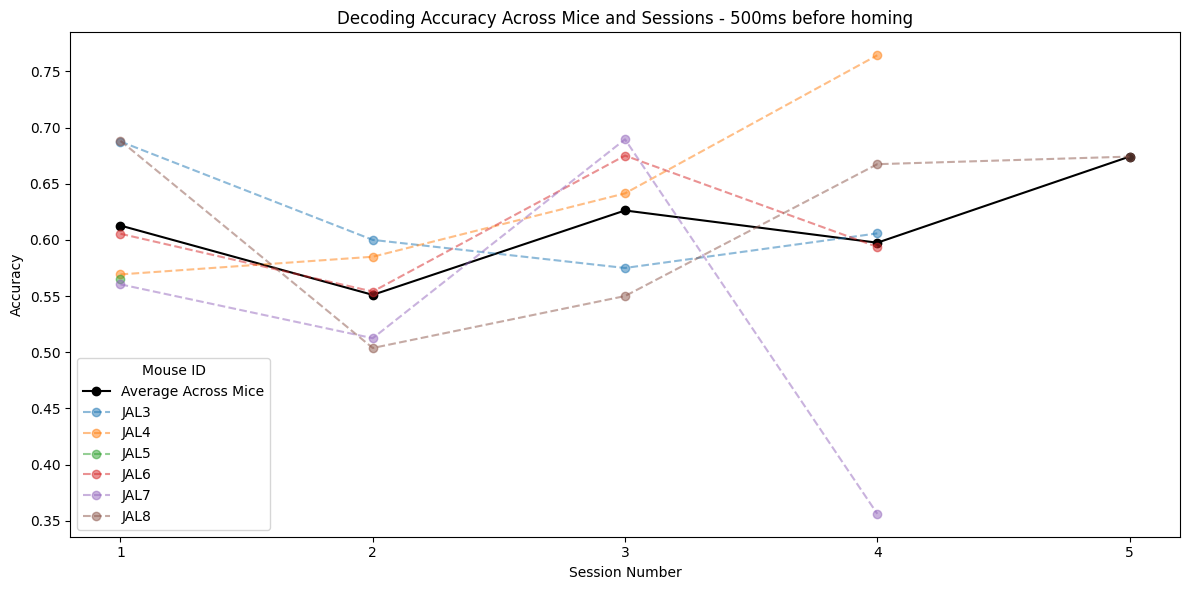

In [19]:
plot_accuracy_across_sessions(model_accuracy, mice_groups=mice_groups, plot_title="500ms before homing")

# Pull out the specific cell IDs of top cells so we can see what their receptive fields look like by going through the single cluster plots

In [ ]:
_14th_may_coefs = average_coefs["JAL8_14may"]
_7th_may_coefs = average_coefs["JAL8_flip3_7may"]

# Load the followng numpy arrau
_14_file = np.load(r"W:\branco\Laurence\JAL008\JAL008_shelter_barrier_flip_5_2024_05_14T10_18_03\processed_data\good_cluster_Ids.npy")
_7_file = np.load(r"W:\branco\Laurence\JAL008\JAL008_shelter_barrier_flip_3_2024_05_07T10_16_26\processed_data\good_cluster_Ids.npy")

# Acess the top positive 10 coefficients for the 14th may
_14th_may_indices = np.argsort(_14th_may_coefs)[::-1][:10]

print("The top 10 positive coefficients for the 14th may are", _14th_may_indices)
print("The top 10 positive coefficients for the 14th may are", _14th_may_coefs[_14th_may_indices])
print("The cell IDs for the 14th may are", sorted(_14_file[_14th_may_indices]))

# Acess the top positive 10 coefficients for the 7th may
_7th_may_indices = np.argsort(_7th_may_coefs)[::-1][:10]

print("The top 10 positive coefficients for the 7th may are", _7th_may_indices)
print("The top 10 positive coefficients for the 7th may are", _7th_may_coefs[_7th_may_indices])
print("The cell IDs for the 7th may are", sorted(_7_file[_7th_may_indices]))
